[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/doxav/astromodel_proving/blob/main/analysis/07_assumption_sensitivity.ipynb)

# Step 07 — Assumption sensitivity: gating, proxy, and compartment split

This notebook runs the local Step 07 pipeline without Google Drive dependencies and writes auditable outputs under `outputs/assumption_sensitivity/`.

**Claim scope:** Step 07 audits whether Step 04–06 conclusions are robust to modeling assumptions. It does not authorize final biological degeneracy wording because parameter plausibility and synthesis checks remain pending.

In [1]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", ".")).resolve()
PROJECT_ROOT

PosixPath('/workspace/astromodel_proving')

In [2]:
from src.step07_assumption_sensitivity import Step07Config, run_step07_assumption_sensitivity

config = Step07Config(max_candidates=2, time_points=40, write_outputs=True)
result = run_step07_assumption_sensitivity(PROJECT_ROOT, config)
result["analysis_summary"]

{'step_name': 'Step 07 — Assumption sensitivity: gating, proxy, and compartment split',
 'config': {'max_candidates': 2,
  'time_points': 40,
  't_final_ms': 50000.0,
  'gating_families': ('sigmoid',
   'tanh',
   'hill',
   'soft_threshold',
   'hard_threshold',
   'double_sigmoid'),
  'currents_na': (100,),
  'proxy_corr_min': 0.5,
  'proxy_rmse_max': 1.25,
  'gating_divergence_rmse_max_mV': 8.0,
  'heldout_pass_min': 0.3,
  'write_outputs': True},
 'n_candidates': 2,
 'n_gating_rows': 12,
 'n_proxy_rows': 2,
 'n_compartment_rows': 2,
 'gating_families': ['sigmoid',
  'tanh',
  'hill',
  'soft_threshold',
  'hard_threshold',
  'double_sigmoid'],
 'claim_scope': 'Step 07 can mark assumptions robust or model-dependent, but final biological degeneracy claims remain disallowed until later plausibility/statistical checks pass.',
 'elapsed_seconds': 0.8463662430003751}

## Accepted ensemble inventory

The Step 07 input contract preserves cell identity, region, condition, candidate ID, and mechanism labels from upstream steps.

In [3]:
gating = result["gating_family_comparison"]
inventory = gating[["file_id", "region", "condition", "candidate_id", "mechanism_cluster", "dominant_mechanism"]].drop_duplicates()
inventory.head(12)

,file_id,region,condition,candidate_id,mechanism_cluster,dominant_mechanism
0,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,M1,Mixed
6,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,M1,Mixed


## Gating-family comparison

All configured gating families are scored using the same candidate/current/time-grid contract.

In [4]:
gating[["gating_family", "region", "condition", "candidate_id", "current_na", "simulation_status", "trace_rmse_vs_sigmoid_mV", "family_supported_under_same_contract", "mechanism_claim_stable"]].head(18)

,gating_family,region,condition,candidate_id,current_na,simulation_status,trace_rmse_vs_sigmoid_mV,family_supported_under_same_contract,mechanism_claim_stable
0,sigmoid,DH,CONTROL,1_DH_1__cand_01__base,100,ok,0.000000,True,True
1,tanh,DH,CONTROL,1_DH_1__cand_01__base,100,ok,0.010597,True,True
2,hill,DH,CONTROL,1_DH_1__cand_01__base,100,ok,0.023136,True,True
3,soft_threshold,DH,CONTROL,1_DH_1__cand_01__base,100,ok,0.022939,True,True
4,hard_threshold,DH,CONTROL,1_DH_1__cand_01__base,100,ok,0.023161,True,True
5,double_sigmoid,DH,CONTROL,1_DH_1__cand_01__base,100,ok,3.815294,True,True
6,sigmoid,DH,CONTROL,1_DH_1__cand_02__low_gap,100,ok,0.000000,True,True
7,tanh,DH,CONTROL,1_DH_1__cand_02__low_gap,100,ok,0.009674,True,True
8,hill,DH,CONTROL,1_DH_1__cand_02__low_gap,100,ok,0.021289,True,True
9,soft_threshold,DH,CONTROL,1_DH_1__cand_02__low_gap,100,ok,0.021105,True,True


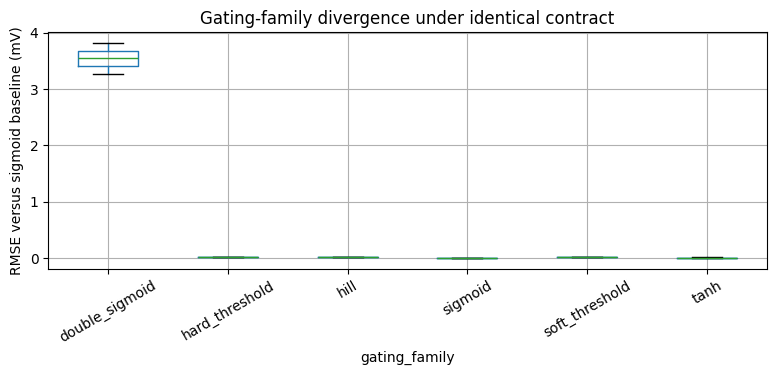

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = gating[gating["simulation_status"].eq("ok")].copy()
if not plot_df.empty:
    plot_df.boxplot(column="trace_rmse_vs_sigmoid_mV", by="gating_family", ax=ax, rot=30)
    ax.set_ylabel("RMSE versus sigmoid baseline (mV)")
    ax.set_title("Gating-family divergence under identical contract")
    fig.suptitle("")
else:
    ax.text(0.5, 0.5, "No successful gating simulations", ha="center")
plt.tight_layout()

## Model-comparison summary

In [6]:
model = result["model_comparison"]
model

,model_family,assumption_axis,n_candidate_current_rows,n_successful_simulations,mean_trace_rmse_vs_sigmoid_mV,median_step04_trace_rmse_mV,mean_heldout_pass_fraction,same_split_same_loss_contract,mechanism_stability_fraction,claim_scope
0,double_sigmoid,gating_form,2,2,3.545108,12.419387,0.340218,step07_same_candidates_currents_timegrid_loss_v1,1.0,robust_across_configured_gating_families
1,hard_threshold,gating_form,2,2,0.022237,12.419387,0.340218,step07_same_candidates_currents_timegrid_loss_v1,1.0,robust_across_configured_gating_families
2,hill,gating_form,2,2,0.022213,12.419387,0.340218,step07_same_candidates_currents_timegrid_loss_v1,1.0,robust_across_configured_gating_families
3,sigmoid,gating_form,2,2,0.000000,12.419387,0.340218,step07_same_candidates_currents_timegrid_loss_v1,1.0,robust_across_configured_gating_families
4,soft_threshold,gating_form,2,2,0.022022,12.419387,0.340218,step07_same_candidates_currents_timegrid_loss_v1,1.0,robust_across_configured_gating_families
5,tanh,gating_form,2,2,0.010135,12.419387,0.340218,step07_same_candidates_currents_timegrid_loss_v1,1.0,robust_across_configured_gating_families


## Intracellular K proxy validity

The local intracellular proxy `ΔK_a,t` is compared with simulated extracellular `K_o` using correlation, scaled RMSE, and lag metrics. Rows that fail criteria explicitly require an ECS variant or additional data.

In [7]:
proxy = result["proxy_validity_by_ensemble"]
proxy[["file_id", "region", "condition", "candidate_id", "current_na", "pearson_r", "spearman_r", "scaled_rmse", "best_lag_samples", "proxy_validity_status", "explicit_ecs_variant_required"]].head(12)

,file_id,region,condition,candidate_id,current_na,pearson_r,spearman_r,scaled_rmse,best_lag_samples,proxy_validity_status,explicit_ecs_variant_required
0,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,100,-0.189161,-0.547680,0.981946,8,proxy_limited,True
1,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,100,-0.187246,-0.609006,0.982313,8,proxy_limited,True


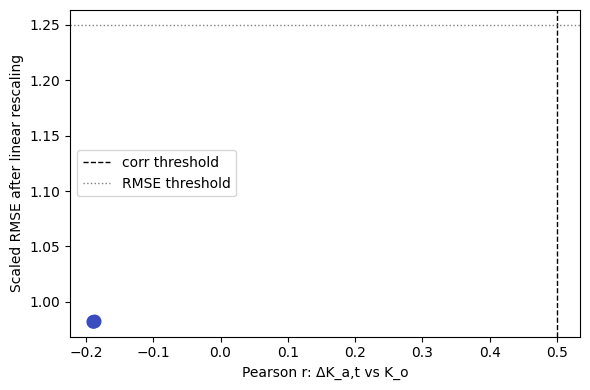

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
if not proxy.empty:
    ax.scatter(proxy["pearson_r"], proxy["scaled_rmse"], c=proxy["explicit_ecs_variant_required"].astype(int), cmap="coolwarm", s=80)
    ax.axvline(config.proxy_corr_min, color="black", linestyle="--", linewidth=1, label="corr threshold")
    ax.axhline(config.proxy_rmse_max, color="gray", linestyle=":", linewidth=1, label="RMSE threshold")
    ax.set_xlabel("Pearson r: ΔK_a,t vs K_o")
    ax.set_ylabel("Scaled RMSE after linear rescaling")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No proxy rows", ha="center")
plt.tight_layout()

## Compartment-split sensitivity

The two-state local proxy is compared with a one-state aggregate proxy. This is a sensitivity score rather than a replacement model fit.

In [9]:
split = result["compartment_split_sensitivity"]
split[["file_id", "region", "condition", "candidate_id", "current_na", "two_state_proxy_abs_corr", "one_state_proxy_abs_corr", "corr_delta_one_minus_two", "split_sensitivity_status", "mechanism_structure_persists"]].head(12)

,file_id,region,condition,candidate_id,current_na,two_state_proxy_abs_corr,one_state_proxy_abs_corr,corr_delta_one_minus_two,split_sensitivity_status,mechanism_structure_persists
0,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,100,0.189161,0.188457,-0.000704,split_robust,True
1,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,100,0.187246,0.188684,0.001437,split_robust,True


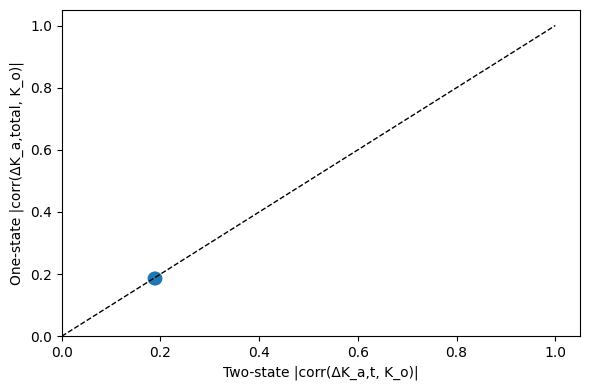

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
if not split.empty:
    ax.scatter(split["two_state_proxy_abs_corr"], split["one_state_proxy_abs_corr"], s=80)
    ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Two-state |corr(ΔK_a,t, K_o)|")
    ax.set_ylabel("One-state |corr(ΔK_a,total, K_o)|")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
else:
    ax.text(0.5, 0.5, "No compartment rows", ha="center")
plt.tight_layout()

## Conservative claim scope

Final biological degeneracy language remains disallowed after Step 07. The table below separates robust, model-dependent, and unresolved assumption axes.

In [11]:
claims = result["claim_scope_table"]
claims

,assumption_axis,status,final_degeneracy_claim_allowed_after_step07
0,gating_form,robust,False
1,intracellular_K_as_ECS_proxy,explicit_ecs_variant_or_extra_data_needed,False
2,local_syncytial_compartment_split,split_robust,False


In [12]:
output_dir = PROJECT_ROOT / "outputs" / "assumption_sensitivity"
print("Wrote:")
for path in sorted(output_dir.glob("*")):
    print("-", path.relative_to(PROJECT_ROOT))

Wrote:
- outputs/assumption_sensitivity/analysis_summary.json
- outputs/assumption_sensitivity/claim_scope_table.csv
- outputs/assumption_sensitivity/compartment_split_sensitivity.csv
- outputs/assumption_sensitivity/gating_family_comparison.csv
- outputs/assumption_sensitivity/model_comparison.csv
- outputs/assumption_sensitivity/proxy_validity_by_ensemble.csv
